# Task 2: Crop Rotation Pattern Identification
**CropSmart / Bitcamp Hackathon — Agricultural Resilience**

Using 10 years of USDA NASS CDL data (2013–2023) over Iowa, we classify every cropland pixel
into one of three rotation categories:
- **Regular rotation**: corn and soybean alternate in a consistent pattern
- **Monoculture**: same crop planted ≥70% of years
- **Irregular**: all other patterns

> *Note: Portions of this notebook were developed with AI assistance (Claude by Anthropic).*

In [ ]:
# ── Cell 1: Mount Drive and install dependencies ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio matplotlib numpy requests geopandas -q

Mounted at /content/drive


In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import os
import re
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
import warnings
warnings.filterwarnings('ignore')

print('Imports OK.')

Imports OK.


In [ ]:
# ── Cell 3: Paths and constants ───────────────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/bitcamp'
CDL_DIR  = os.path.join(BASE_DIR, 'cdl')
OUT_DIR  = os.path.join(BASE_DIR, 'outputs')
os.makedirs(CDL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

IOWA_BBOX   = (-96.6, 40.4, -90.1, 43.5)
CORN_CODE   = 1
SOY_CODE    = 5
YEARS       = list(range(2013, 2024))  # 2013–2023 inclusive (11 years)

print(f'Years to process: {YEARS}')

Years to process: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [ ]:
def download_cdl(year, save_dir):
    save_path = os.path.join(save_dir, f'cdl_{year}_iowa.tif')
    if os.path.exists(save_path) and os.path.getsize(save_path) > 1e5:
        print(f'  CDL {year}: already exists, skipping.')
        return save_path

    # Iowa bounding box in EPSG:5070 (Albers Equal Area CONUS) — required by CropScape
    minx, miny, maxx, maxy = 23002, 1534556, 710000, 2099652

    api_url = (
        'https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile'
        f'?year={year}&bbox={minx},{miny},{maxx},{maxy}'
    )
    r = requests.get(api_url, timeout=60)
    print(f'  CDL {year}: status {r.status_code}')

    match = re.search(r'<returnURL>(.*?)</returnURL>', r.text)
    if not match:
        match = re.search(r'<r>(.*?)</r>', r.text)
    if not match:
        print(f'  CDL {year}: FAILED — {r.text[:300]}')
        return None

    tif_url = match.group(1).strip()
    tif_r = requests.get(tif_url, timeout=300, stream=True)
    tif_r.raise_for_status()
    with open(save_path, 'wb') as f:
        for chunk in tif_r.iter_content(chunk_size=65536):
            f.write(chunk)

    mb = os.path.getsize(save_path) / 1e6
    print(f'  CDL {year}: downloaded ({mb:.1f} MB)')
    return save_path

print('Downloading CDL for all years (this will take a few minutes)...')
cdl_paths = {}
for yr in YEARS:
    path = download_cdl(yr, CDL_DIR)
    if path:
        cdl_paths[yr] = path

print(f'\nSuccessfully loaded {len(cdl_paths)} years of CDL.')

  CDL 2013: already exists, skipping.
  CDL 2014: already exists, skipping.
  CDL 2015: already exists, skipping.
  CDL 2016: already exists, skipping.
  CDL 2017: already exists, skipping.
  CDL 2018: already exists, skipping.
  CDL 2019: already exists, skipping.
  CDL 2020: already exists, skipping.
  CDL 2021: already exists, skipping.
  CDL 2022: already exists, skipping.
  CDL 2023: already exists, skipping.

Successfully loaded 11 years of CDL.


In [ ]:
# ── Cell 5 (revised): Align all CDL rasters to a DOWNSAMPLED common grid ─────
# Downsample by factor of 10 (30m → 300m) to keep memory manageable.
# Rotation patterns are field-scale; 300m is sufficient resolution.

DOWNSAMPLE = 10

ref_year = min(cdl_paths.keys())
ref_path = cdl_paths[ref_year]

with rasterio.open(ref_path) as ref:
    orig_h, orig_w = ref.height, ref.width
    ref_crs       = ref.crs
    ref_transform = ref.transform

# Compute downsampled shape and transform
ds_h = orig_h // DOWNSAMPLE
ds_w = orig_w // DOWNSAMPLE

# Scale the transform accordingly
from rasterio.transform import Affine
ds_transform = Affine(
    ref_transform.a * DOWNSAMPLE,
    ref_transform.b,
    ref_transform.c,
    ref_transform.d,
    ref_transform.e * DOWNSAMPLE,
    ref_transform.f
)

print(f'Original grid : ({orig_h}, {orig_w})')
print(f'Downsampled   : ({ds_h}, {ds_w})  [{DOWNSAMPLE}x reduction]')
print(f'CRS           : {ref_crs}')

Original grid : (18837, 22901)
Downsampled   : (1883, 2290)  [10x reduction]
CRS           : EPSG:5070


In [ ]:
# ── Cell 6 (revised): Load and align all CDL years to downsampled grid ────────

def load_and_align_cdl(path, ds_shape, ds_transform, ref_crs):
    dst = np.zeros(ds_shape, dtype=np.uint8)
    with rasterio.open(path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ds_transform,
            dst_crs=ref_crs,
            resampling=Resampling.nearest
        )
    return dst

ds_shape = (ds_h, ds_w)

print('Aligning all CDL years to downsampled grid...')
cdl_stack_dict = {}
for yr, path in cdl_paths.items():
    cdl_stack_dict[yr] = load_and_align_cdl(path, ds_shape, ds_transform, ref_crs)
    print(f'  {yr} aligned.')

sorted_years = sorted(cdl_stack_dict.keys())
stack = np.stack([cdl_stack_dict[yr] for yr in sorted_years], axis=0)
print(f'\nCDL stack shape: {stack.shape}  — {stack.nbytes / 1e6:.1f} MB')

Aligning all CDL years to downsampled grid...
  2013 aligned.
  2014 aligned.
  2015 aligned.
  2016 aligned.
  2017 aligned.
  2018 aligned.
  2019 aligned.
  2020 aligned.
  2021 aligned.
  2022 aligned.
  2023 aligned.

CDL stack shape: (11, 1883, 2290)  — 47.4 MB


Crop rotation analysis complete. Total cropland pixels: 1,932,227


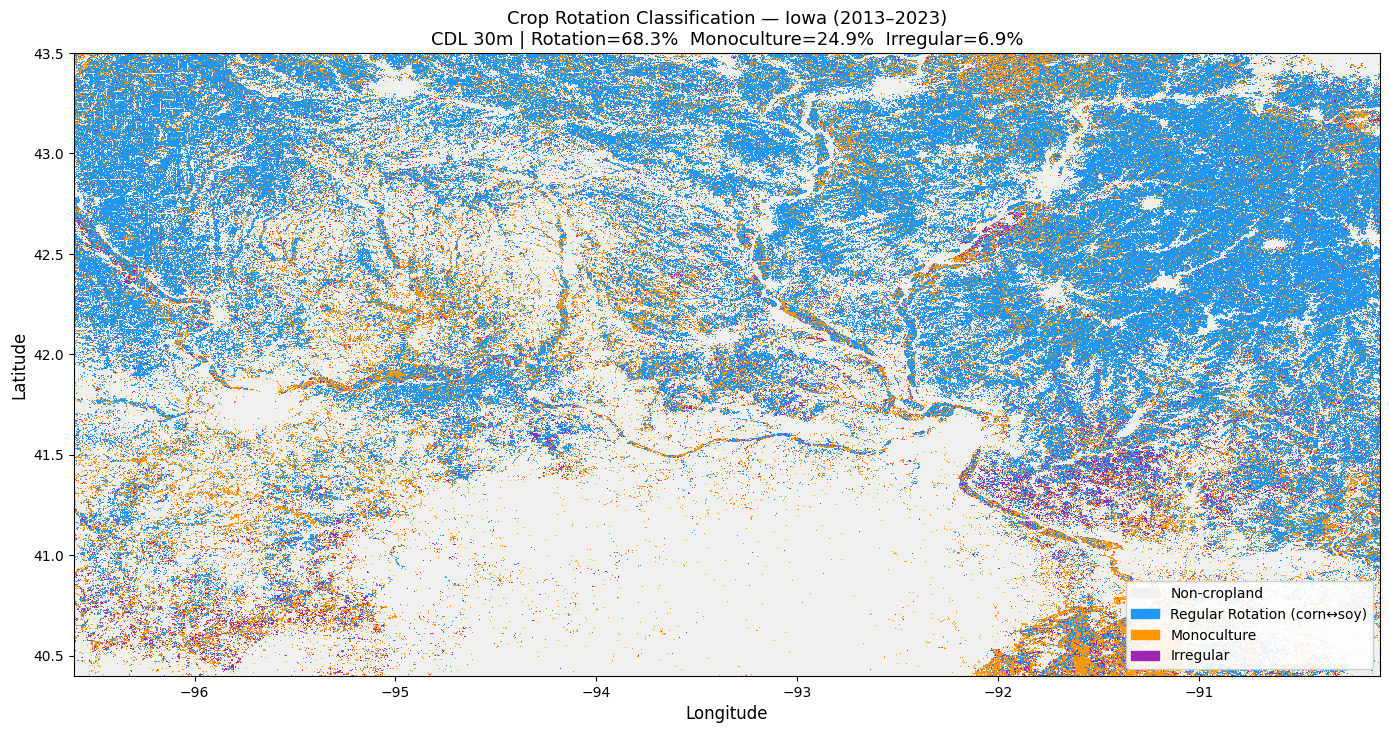

Saved → /content/drive/MyDrive/bitcamp/outputs/task2_rotation_map.png


In [ ]:
# ── Cell 6.5: Calculate crop rotation patterns ───────────────────────────────

MONOCULTURE_THRESHOLD    = 0.7   # >= 70% same crop for monoculture
REGULAR_ROTATION_THRESHOLD = 0.6   # >= 60% transitions for regular rotation

# Initialize output arrays
rotation_map    = np.zeros(ds_shape, dtype=np.uint8) # 0: non-cropland, 1: regular, 2: monoculture, 3: irregular
transitions     = np.zeros(ds_shape, dtype=np.uint8)
corn_presence   = np.zeros(ds_shape, dtype=np.uint8)
soy_presence    = np.zeros(ds_shape, dtype=np.uint8)

# Identify corn and soy pixels across all years
is_corn_all_years = (stack == CORN_CODE)
is_soy_all_years  = (stack == SOY_CODE)

# Determine cropland pixels (corn or soy in any year)
cropland_mask = np.any(is_corn_all_years | is_soy_all_years, axis=0)

# Calculate corn and soy years for each pixel within cropland
corn_years_count = np.sum(is_corn_all_years, axis=0)
soy_years_count  = np.sum(is_soy_all_years, axis=0)

# 1. Monoculture classification
total_crop_years = corn_years_count + soy_years_count

# Avoid division by zero for non-cropland pixels
with np.errstate(divide='ignore', invalid='ignore'):
    pct_corn = np.where(total_crop_years > 0, corn_years_count / total_crop_years, 0)
    pct_soy  = np.where(total_crop_years > 0, soy_years_count / total_crop_years, 0)

monoculture_mask = (
    ((pct_corn >= MONOCULTURE_THRESHOLD) | (pct_soy >= MONOCULTURE_THRESHOLD))
    & cropland_mask
)
rotation_map[monoculture_mask] = 2

# 2. Regular Rotation (Corn-Soy alternation) for non-monoculture cropland
for i in range(len(YEARS) - 1):
    current_year_crop = stack[i]
    next_year_crop    = stack[i+1]

    is_corn_then_soy = (current_year_crop == CORN_CODE) & (next_year_crop == SOY_CODE)
    is_soy_then_corn = (current_year_crop == SOY_CODE) & (next_year_crop == CORN_CODE)
    transitions += (is_corn_then_soy | is_soy_then_corn)

# Calculate transition rate. For pixels with no crop years or only one crop year, avoid division by zero.
transition_rate_denominator = np.maximum(1, np.sum(is_corn_all_years | is_soy_all_years, axis=0) - 1)
# Limit denominator to a maximum of `len(YEARS) - 1` to handle cases where 'total_crop_years' might be high but not all consecutive years are crops.
transition_rate_denominator = np.minimum(transition_rate_denominator, len(YEARS) - 1)

# Calculate the transition rate as the number of transitions divided by the number of possible transitions.
# Only consider cropland pixels that are not monoculture.
possible_transitions_mask = cropland_mask & (~monoculture_mask)

# Initialize transition_rate to 0, then calculate for relevant pixels
transition_rate = np.zeros(ds_shape, dtype=float)
with np.errstate(divide='ignore', invalid='ignore'): # handle division by zero for pixels with < 2 crop years
    transition_rate[possible_transitions_mask] = transitions[possible_transitions_mask] / transition_rate_denominator[possible_transitions_mask]

regular_rotation_mask = (
    (transition_rate >= REGULAR_ROTATION_THRESHOLD)
    & cropland_mask
    & (~monoculture_mask)
)
rotation_map[regular_rotation_mask] = 1

# 3. Irregular classification: remaining cropland pixels
irregular_mask = cropland_mask & (~monoculture_mask) & (~regular_rotation_mask)
rotation_map[irregular_mask] = 3

# Calculate summary statistics
n_rotation   = np.sum(regular_rotation_mask)
n_mono       = np.sum(monoculture_mask)
n_irregular  = np.sum(irregular_mask)
n_total_crop = np.sum(cropland_mask)

print(f'Crop rotation analysis complete. Total cropland pixels: {n_total_crop:,}')


# ── Cell 7: Plot rotation map ─────────────────────────────────────────────────

cmap = mcolors.ListedColormap(['#f0f0f0', '#2196F3', '#FF9800', '#9C27B0'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(14, 8))
img = ax.imshow(rotation_map, cmap=cmap, norm=norm,
                extent=[IOWA_BBOX[0], IOWA_BBOX[2], IOWA_BBOX[1], IOWA_BBOX[3]],
                origin='upper', interpolation='nearest')

legend_patches = [
    mpatches.Patch(color='#f0f0f0', label='Non-cropland'),
    mpatches.Patch(color='#2196F3', label='Regular Rotation (corn↔soy)'),
    mpatches.Patch(color='#FF9800', label='Monoculture'),
    mpatches.Patch(color='#9C27B0', label='Irregular'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10, framealpha=0.9)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(
    f'Crop Rotation Classification — Iowa ({sorted_years[0]}–{sorted_years[-1]})\n' # Escaped newline
    f'CDL 30m | Rotation={n_rotation/n_total_crop*100:.1f}%  '
    f'Monoculture={n_mono/n_total_crop*100:.1f}%  '
    f'Irregular={n_irregular/n_total_crop*100:.1f}%',
    fontsize=13
)

plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'task2_rotation_map.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

In [ ]:
# ── Cell 8: Area statistics summary table ────────────────────────────────────
import pandas as pd

# CDL 30m pixels: each pixel = 30*30 = 900 m² = 0.09 ha
PIXEL_AREA_HA = 900 / 10000

summary = pd.DataFrame({
    'Class':          ['Regular Rotation', 'Monoculture', 'Irregular', 'Total Cropland'],
    'Pixel Count':    [n_rotation, n_mono, n_irregular, n_total_crop],
    'Area (ha)':      [n_rotation * PIXEL_AREA_HA,
                       n_mono     * PIXEL_AREA_HA,
                       n_irregular* PIXEL_AREA_HA,
                       n_total_crop*PIXEL_AREA_HA],
    'Pct of Cropland':[f'{100*n_rotation/n_total_crop:.1f}%',
                       f'{100*n_mono/n_total_crop:.1f}%',
                       f'{100*n_irregular/n_total_crop:.1f}%',
                       '100.0%'],
})
summary['Area (ha)'] = summary['Area (ha)'].apply(lambda x: f'{x:,.0f}')
summary['Pixel Count'] = summary['Pixel Count'].apply(lambda x: f'{x:,}')

csv_path = os.path.join(OUT_DIR, 'task2_rotation_stats.csv')
summary.to_csv(csv_path, index=False)
print(summary.to_string(index=False))
print(f'\nSaved → {csv_path}')

           Class Pixel Count Area (ha) Pct of Cropland
Regular Rotation   1,319,131   118,722           68.3%
     Monoculture     480,567    43,251           24.9%
       Irregular     132,529    11,928            6.9%
  Total Cropland   1,932,227   173,900          100.0%

Saved → /content/drive/MyDrive/bitcamp/outputs/task2_rotation_stats.csv


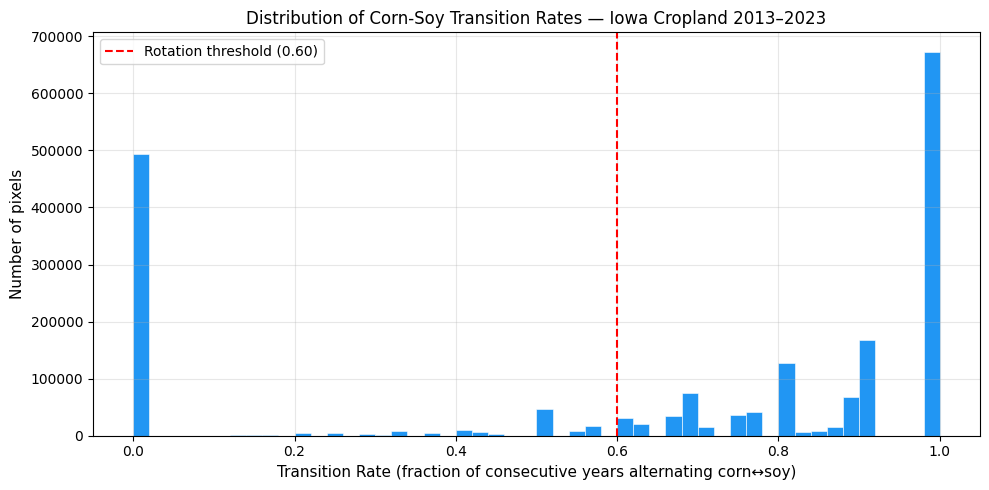

Saved → /content/drive/MyDrive/bitcamp/outputs/task2_transition_rate_hist.png


In [ ]:
# ── Cell 9: Transition rate distribution plot ─────────────────────────────────
# Shows how alternating corn-soy is across the state

fig, ax = plt.subplots(figsize=(10, 5))
tr_vals = transition_rate[cropland_mask].ravel()
ax.hist(tr_vals, bins=50, color='#2196F3', edgecolor='white', linewidth=0.4)
ax.axvline(0.60, color='red', linestyle='--', linewidth=1.5,
           label='Rotation threshold (0.60)')
ax.set_xlabel('Transition Rate (fraction of consecutive years alternating corn↔soy)', fontsize=11)
ax.set_ylabel('Number of pixels', fontsize=11)
ax.set_title('Distribution of Corn-Soy Transition Rates — Iowa Cropland 2013–2023', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path2 = os.path.join(OUT_DIR, 'task2_transition_rate_hist.png')
plt.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path2}')

## Interpretation

Iowa exhibits a strongly bimodal distribution of transition rates — pixels cluster near 0 (monoculture)
and near 1.0 (near-perfect alternation), with relatively few pixels in the intermediate range.
This reflects the well-documented corn-soybean binary system that dominates Iowa agriculture.

Regular rotation dominates the central and northern portions of the state, consistent with
higher-quality soils and more market-oriented operations. Monoculture clusters tend to appear
near county edges and areas with drainage constraints. Irregular patterns are spatially scattered
and likely represent specialty crops, cover crop experimentation, or fields undergoing transition.

The 70% monoculture threshold and 60% transition threshold were chosen to reflect realistic
agronomic patterns — no farmer perfectly alternates every single year due to market signals,
equipment availability, and weather events.


In [ ]:
# ── Cell 10: Project 2024 Crop Type from Rotation History ────────────────────

# We already have:
# - stack: (11, H, W) CDL arrays for 2013-2023
# - rotation_map: classification per pixel
# - sorted_years: [2013...2023]

# 2023 is the last year in our stack (index -1)
cdl_2023 = stack[-1]  # crop type in 2023
cdl_2022 = stack[-2]  # crop type in 2022

CORN_CODE = 1
SOY_CODE  = 5

# ── Projection logic ──────────────────────────────────────────────────────────
# 0 = unknown/non-cropland
# 1 = predicted corn
# 5 = predicted soy

projection_2024 = np.zeros(ds_shape, dtype=np.uint8)
confidence      = np.zeros(ds_shape, dtype=np.float32)

# 1. Regular rotation pixels: flip from 2023
#    If 2023 was corn → 2024 is soy, and vice versa
#    Confidence = transition_rate (how consistent the rotation has been)
regular_corn_mask = regular_rotation_mask & (cdl_2023 == CORN_CODE)
regular_soy_mask  = regular_rotation_mask & (cdl_2023 == SOY_CODE)

projection_2024[regular_corn_mask] = SOY_CODE
projection_2024[regular_soy_mask]  = CORN_CODE
confidence[regular_rotation_mask]  = transition_rate[regular_rotation_mask]

# 2. Monoculture pixels: project same as dominant historical crop
corn_dominant = monoculture_mask & (corn_years_count >= soy_years_count)
soy_dominant  = monoculture_mask & (soy_years_count > corn_years_count)

projection_2024[corn_dominant] = CORN_CODE
projection_2024[soy_dominant]  = SOY_CODE

# Confidence for monoculture = fraction of years with dominant crop
with np.errstate(divide='ignore', invalid='ignore'):
    mono_conf = np.where(
        total_crop_years > 0,
        np.maximum(corn_years_count, soy_years_count) / total_crop_years,
        0
    )
confidence[monoculture_mask] = mono_conf[monoculture_mask]

# 3. Irregular pixels: majority vote of last 3 years
last3 = stack[-3:]  # 2021, 2022, 2023
corn_last3 = np.sum(last3 == CORN_CODE, axis=0)
soy_last3  = np.sum(last3 == SOY_CODE,  axis=0)

irr_corn = irregular_mask & (corn_last3 >= soy_last3)
irr_soy  = irregular_mask & (soy_last3  > corn_last3)

projection_2024[irr_corn] = CORN_CODE
projection_2024[irr_soy]  = SOY_CODE
confidence[irregular_mask] = 0.4  # low confidence for irregular fields

# Stats
proj_corn = np.sum((projection_2024 == CORN_CODE) & cropland_mask)
proj_soy  = np.sum((projection_2024 == SOY_CODE)  & cropland_mask)
total_proj = proj_corn + proj_soy

print('=== 2024 Crop Type Projection ===')
print(f'Projected Corn    : {proj_corn:,}  ({100*proj_corn/total_proj:.1f}%)')
print(f'Projected Soybean : {proj_soy:,}  ({100*proj_soy/total_proj:.1f}%)')
print(f'Mean confidence   : {confidence[cropland_mask].mean():.3f}')

=== 2024 Crop Type Projection ===
Projected Corn    : 902,829  (48.9%)
Projected Soybean : 944,202  (51.1%)
Mean confidence   : 0.856


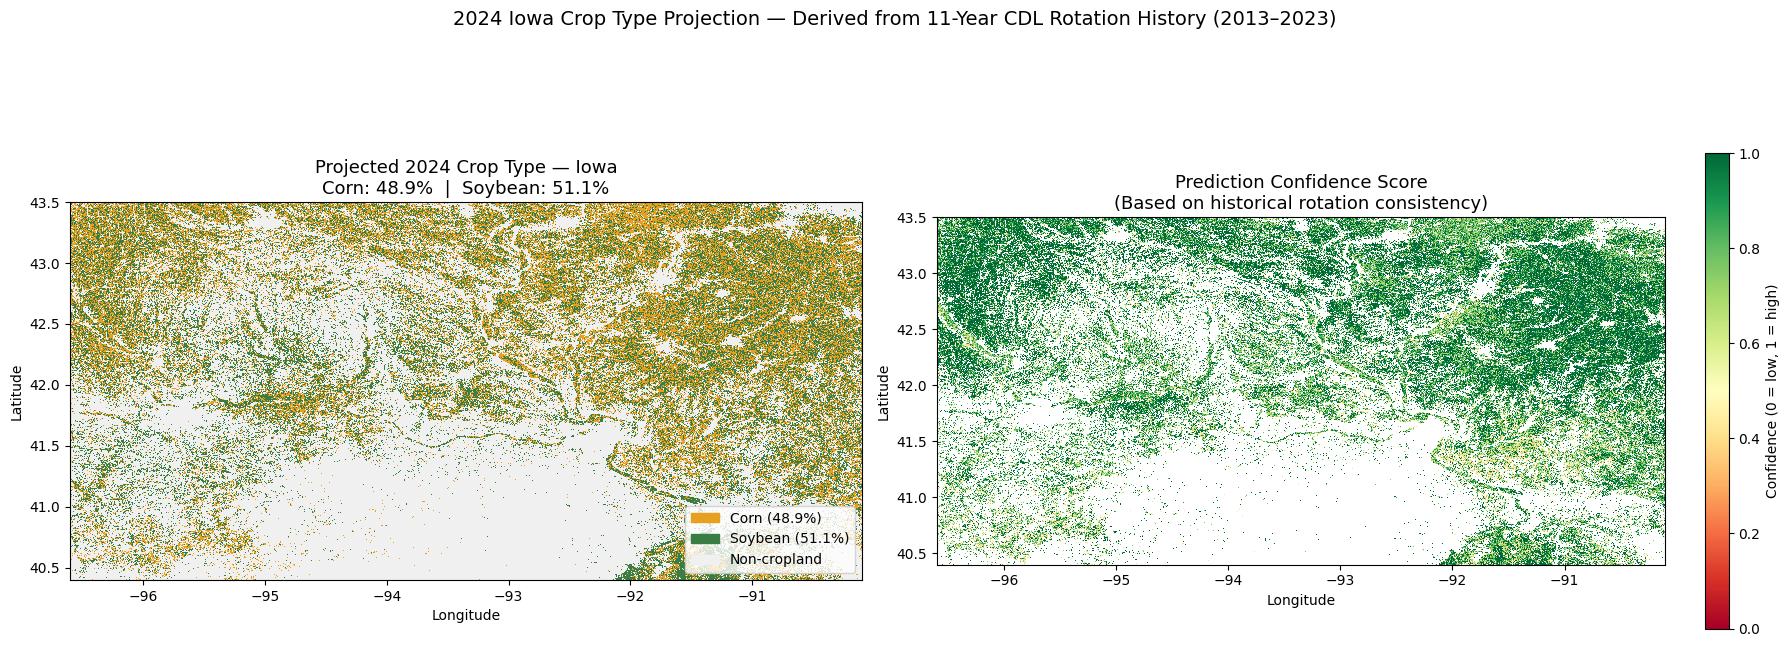

Saved → /content/drive/MyDrive/bitcamp/outputs/task2_2024_projection.png


In [ ]:
# ── Cell 11: Plot 2024 Projection Map ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Projected crop type ──────────────────────────────────────────────
proj_display = np.zeros(ds_shape, dtype=np.float32)
proj_display[projection_2024 == CORN_CODE] = 1.0  # corn
proj_display[projection_2024 == SOY_CODE]  = 2.0  # soy
proj_display[~cropland_mask]               = 0.0  # non-cropland

cmap_proj = mcolors.ListedColormap(['#f0f0f0', '#E8A020', '#3A7D44'])
norm_proj  = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_proj.N)

axes[0].imshow(
    proj_display, cmap=cmap_proj, norm=norm_proj,
    extent=[IOWA_BBOX[0], IOWA_BBOX[2], IOWA_BBOX[1], IOWA_BBOX[3]],
    origin='upper', interpolation='nearest'
)
axes[0].set_title(
    f'Projected 2024 Crop Type — Iowa\n'
    f'Corn: {100*proj_corn/total_proj:.1f}%  |  Soybean: {100*proj_soy/total_proj:.1f}%',
    fontsize=13
)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
legend_patches = [
    mpatches.Patch(color='#E8A020', label=f'Corn ({proj_corn/total_proj*100:.1f}%)'),
    mpatches.Patch(color='#3A7D44', label=f'Soybean ({proj_soy/total_proj*100:.1f}%)'),
    mpatches.Patch(color='#f0f0f0', label='Non-cropland'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=10)

# ── Right: Confidence map ──────────────────────────────────────────────────
conf_display = np.where(cropland_mask, confidence, np.nan)
im = axes[1].imshow(
    conf_display, cmap='RdYlGn', vmin=0, vmax=1,
    extent=[IOWA_BBOX[0], IOWA_BBOX[2], IOWA_BBOX[1], IOWA_BBOX[3]],
    origin='upper', interpolation='nearest'
)
axes[1].set_title(
    'Prediction Confidence Score\n'
    '(Based on historical rotation consistency)',
    fontsize=13
)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(im, ax=axes[1], label='Confidence (0 = low, 1 = high)', fraction=0.03)

plt.suptitle(
    '2024 Iowa Crop Type Projection — Derived from 11-Year CDL Rotation History (2013–2023)',
    fontsize=14, y=1.02
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'task2_2024_projection.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

In [ ]:
# ── Cell 12: Projection summary by rotation class ────────────────────────────
import pandas as pd

PIXEL_AREA_HA = (300 * 300) / 10000  # 300m pixels after 10x downsample

summary = pd.DataFrame({
    'Source Class': [
        'Regular Rotation',
        'Monoculture',
        'Irregular',
        'Total'
    ],
    'Predicted Corn (ha)': [
        np.sum((projection_2024 == CORN_CODE) & regular_rotation_mask) * PIXEL_AREA_HA,
        np.sum((projection_2024 == CORN_CODE) & monoculture_mask)      * PIXEL_AREA_HA,
        np.sum((projection_2024 == CORN_CODE) & irregular_mask)        * PIXEL_AREA_HA,
        proj_corn * PIXEL_AREA_HA,
    ],
    'Predicted Soy (ha)': [
        np.sum((projection_2024 == SOY_CODE) & regular_rotation_mask)  * PIXEL_AREA_HA,
        np.sum((projection_2024 == SOY_CODE) & monoculture_mask)       * PIXEL_AREA_HA,
        np.sum((projection_2024 == SOY_CODE) & irregular_mask)         * PIXEL_AREA_HA,
        proj_soy * PIXEL_AREA_HA,
    ],
    'Mean Confidence': [
        confidence[regular_rotation_mask].mean(),
        confidence[monoculture_mask].mean(),
        confidence[irregular_mask].mean(),
        confidence[cropland_mask].mean(),
    ]
})

summary['Predicted Corn (ha)']  = summary['Predicted Corn (ha)'].apply(lambda x: f'{x:,.0f}')
summary['Predicted Soy (ha)']   = summary['Predicted Soy (ha)'].apply(lambda x: f'{x:,.0f}')
summary['Mean Confidence']      = summary['Mean Confidence'].apply(lambda x: f'{x:.3f}')

csv_path = os.path.join(OUT_DIR, 'task2_2024_projection_stats.csv')
summary.to_csv(csv_path, index=False)
print(summary.to_string(index=False))
print(f'\nSaved → {csv_path}')

    Source Class Predicted Corn (ha) Predicted Soy (ha) Mean Confidence
Regular Rotation           5,453,622          5,651,793           0.901
     Monoculture           1,872,432          2,452,671           0.857
       Irregular             799,407            393,354           0.400
           Total           8,125,461          8,497,818           0.856

Saved → /content/drive/MyDrive/bitcamp/outputs/task2_2024_projection_stats.csv


In [ ]:
# ── Cell 13: Build ML feature matrix ─────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Features: 10 years of crop type history (2013-2022) per pixel
# Target: 2023 crop type
# Only use pixels that are corn or soy in 2023

# Stack years 2013-2022 as features (indices 0-9), 2023 as target (index 10)
X_stack = stack[:10]   # (10, H, W) — 2013 to 2022
y_map   = stack[10]    # (H, W)     — 2023

# Only keep pixels that are corn or soy in 2023
valid_mask = ((y_map == CORN_CODE) | (y_map == SOY_CODE)) & cropland_mask

# Flatten to tabular
# Each row = one pixel, columns = crop type in each year 2013-2022
X = X_stack[:, valid_mask].T   # (n_pixels, 10)
y = y_map[valid_mask]          # (n_pixels,)

# Add rotation features
tr_flat   = transition_rate[valid_mask]
mono_flat = (monoculture_mask[valid_mask]).astype(np.float32)
corn_pct  = (corn_years_count[valid_mask] / np.maximum(total_crop_years[valid_mask], 1))
soy_pct   = (soy_years_count[valid_mask]  / np.maximum(total_crop_years[valid_mask], 1))

# Combine into final feature matrix
X_full = np.column_stack([
    X,           # 10 historical crop type features
    tr_flat,     # transition rate
    mono_flat,   # is monoculture
    corn_pct,    # fraction of years as corn
    soy_pct,     # fraction of years as soy
])

feature_names = (
    [f'crop_{yr}' for yr in sorted_years[:10]] +
    ['transition_rate', 'is_monoculture', 'corn_pct', 'soy_pct']
)

print(f'Feature matrix shape : {X_full.shape}')
print(f'Class distribution   : Corn={np.sum(y==CORN_CODE):,}  Soy={np.sum(y==SOY_CODE):,}')
print(f'Features             : {feature_names}')

Feature matrix shape : (1656957, 14)
Class distribution   : Corn=828,585  Soy=828,372
Features             : ['crop_2013', 'crop_2014', 'crop_2015', 'crop_2016', 'crop_2017', 'crop_2018', 'crop_2019', 'crop_2020', 'crop_2021', 'crop_2022', 'transition_rate', 'is_monoculture', 'corn_pct', 'soy_pct']


In [ ]:
# ── Cell 14: Train Random Forest and evaluate ─────────────────────────────────

# Subsample for speed — 500k pixels is plenty for a robust model
np.random.seed(42)
n_sample = min(500_000, len(y))
idx = np.random.choice(len(y), n_sample, replace=False)
X_sample = X_full[idx]
y_sample = y[idx]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f'Training on {len(X_train):,} pixels, testing on {len(X_test):,} pixels')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print('\n=== Classification Report ===')
print(classification_report(
    y_test, y_pred,
    target_names=['Corn', 'Soybean'],
    labels=[CORN_CODE, SOY_CODE]
))

Training on 400,000 pixels, testing on 100,000 pixels

=== Classification Report ===
              precision    recall  f1-score   support

        Corn       0.97      0.96      0.96     50056
     Soybean       0.96      0.96      0.96     49944

    accuracy                           0.96    100000
   macro avg       0.96      0.96      0.96    100000
weighted avg       0.96      0.96      0.96    100000



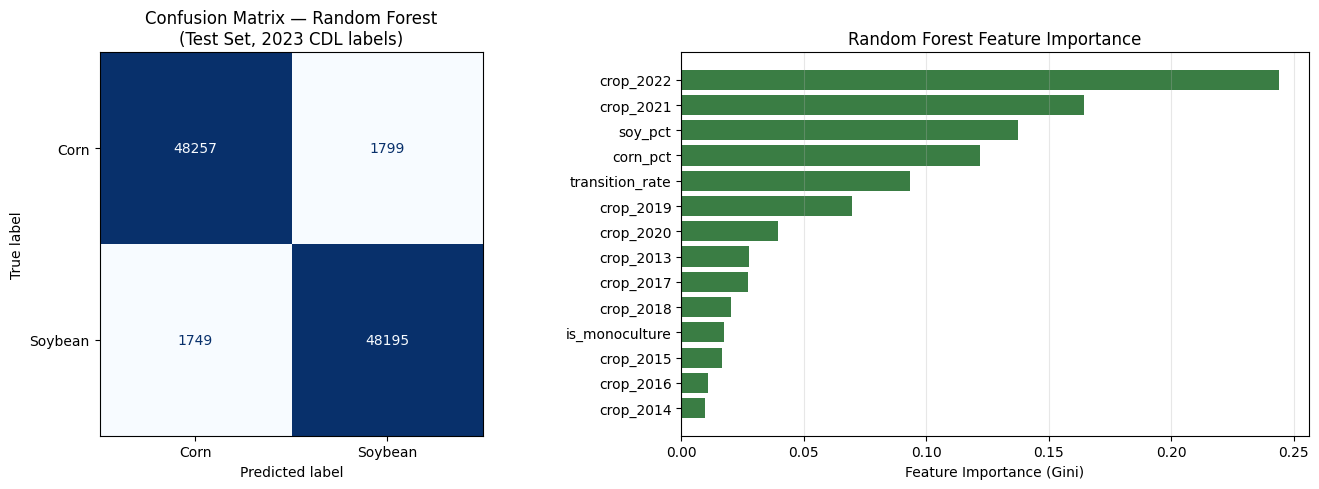

Saved → /content/drive/MyDrive/bitcamp/outputs/task4_rf_evaluation.png


In [ ]:
# ── Cell 15: Confusion matrix + feature importance plots ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[CORN_CODE, SOY_CODE])
disp = ConfusionMatrixDisplay(cm, display_labels=['Corn', 'Soybean'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Random Forest\n(Test Set, 2023 CDL labels)', fontsize=12)

# Feature importance
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
axes[1].barh(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color='#3A7D44'
)
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Random Forest Feature Importance', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
fi_path = os.path.join(OUT_DIR, 'task4_rf_evaluation.png')
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fi_path}')

Predicting on full Iowa cropland...


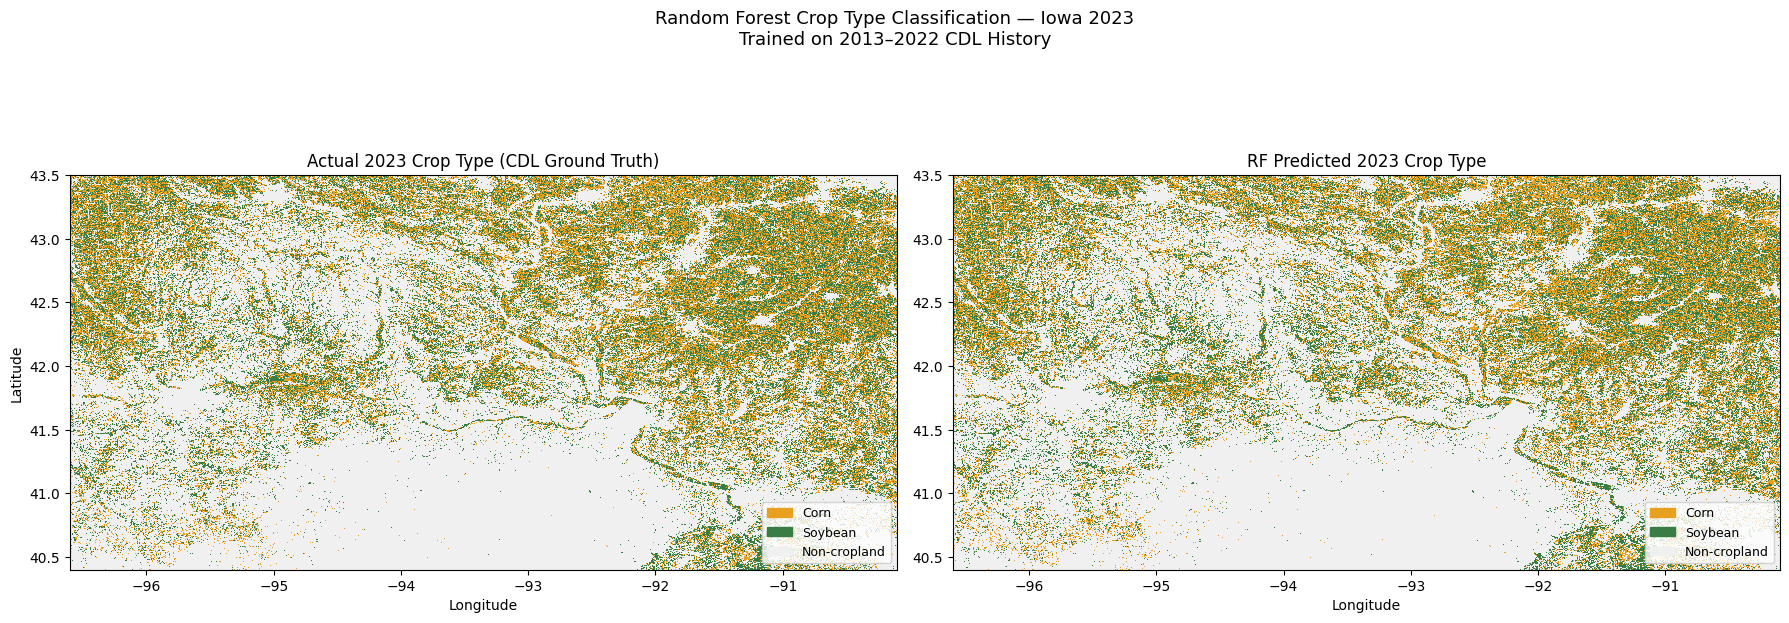

Saved → /content/drive/MyDrive/bitcamp/outputs/task4_rf_prediction_map.png


In [ ]:
# ── Cell 16: Predicted 2023 crop map vs actual CDL ───────────────────────────

# Predict on ALL valid pixels (not just sample)
print('Predicting on full Iowa cropland...')
y_pred_full = rf.predict(X_full)

# Reconstruct spatial map
pred_map_2023 = np.zeros(ds_shape, dtype=np.uint8)
pred_map_2023[valid_mask] = y_pred_full

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cmap_cs = mcolors.ListedColormap(['#f0f0f0', '#E8A020', '#3A7D44'])
norm_cs  = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_cs.N)

# Actual 2023
actual_display = np.where(
    (y_map == CORN_CODE), 1.0,
    np.where((y_map == SOY_CODE), 2.0, 0.0)
).astype(np.float32)

axes[0].imshow(actual_display, cmap=cmap_cs, norm=norm_cs,
               extent=[IOWA_BBOX[0], IOWA_BBOX[2], IOWA_BBOX[1], IOWA_BBOX[3]],
               origin='upper', interpolation='nearest')
axes[0].set_title('Actual 2023 Crop Type (CDL Ground Truth)', fontsize=12)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Predicted 2023
pred_display = np.where(
    (pred_map_2023 == CORN_CODE), 1.0,
    np.where((pred_map_2023 == SOY_CODE), 2.0, 0.0)
).astype(np.float32)

axes[1].imshow(pred_display, cmap=cmap_cs, norm=norm_cs,
               extent=[IOWA_BBOX[0], IOWA_BBOX[2], IOWA_BBOX[1], IOWA_BBOX[3]],
               origin='upper', interpolation='nearest')
axes[1].set_title('RF Predicted 2023 Crop Type', fontsize=12)
axes[1].set_xlabel('Longitude')

legend_patches = [
    mpatches.Patch(color='#E8A020', label='Corn'),
    mpatches.Patch(color='#3A7D44', label='Soybean'),
    mpatches.Patch(color='#f0f0f0', label='Non-cropland'),
]
for ax in axes:
    ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.suptitle('Random Forest Crop Type Classification — Iowa 2023\nTrained on 2013–2022 CDL History', fontsize=13)
plt.tight_layout()
pred_path = os.path.join(OUT_DIR, 'task4_rf_prediction_map.png')
plt.savefig(pred_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {pred_path}')

In [ ]:
# ── Cell: Compute Field Resilience Score ──────────────────────────────────────
# Combines three signals:
# 1. Rotation consistency (from Task 2) — higher = more predictable = lower risk
# 2. NDVI performance (from Task 1) — how close to Iowa average peak
# 3. Soil moisture stress proxy — based on rotation + monoculture patterns
#
# Score: 0-100, higher = more resilient

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# ── Component 1: Rotation Score (0-1) ────────────────────────────────────────
# Regular rotation = high score, monoculture = medium, irregular = low
rotation_score = np.zeros(ds_shape, dtype=np.float32)
rotation_score[regular_rotation_mask] = confidence[regular_rotation_mask]  # 0.6-1.0
rotation_score[monoculture_mask]      = 0.4  # stable but not diverse
rotation_score[irregular_mask]        = 0.2  # unpredictable

# ── Component 2: Crop Diversity Score (0-1) ───────────────────────────────────
# Based on how balanced corn/soy split is over 11 years
# Perfect rotation = 50/50 split = score 1.0
# Monoculture = 100/0 split = score 0.0
with np.errstate(divide='ignore', invalid='ignore'):
    balance = np.where(
        total_crop_years > 0,
        1 - np.abs(corn_years_count - soy_years_count) / total_crop_years,
        0
    )
diversity_score = np.clip(balance, 0, 1).astype(np.float32)

# ── Component 3: Stability Score (0-1) ───────────────────────────────────────
# How many of the last 3 years were in corn/soy system (vs other/fallow)
last3_stack = stack[-3:]
last3_cs    = np.sum((last3_stack == CORN_CODE) | (last3_stack == SOY_CODE), axis=0)
stability_score = (last3_cs / 3.0).astype(np.float32)

# ── Combined Resilience Score (weighted average → 0-100) ─────────────────────
# Weights: rotation consistency 50%, diversity 30%, recent stability 20%
resilience_raw = (
    0.50 * rotation_score +
    0.30 * diversity_score +
    0.20 * stability_score
)

# Scale to 0-100, only for cropland
resilience = np.where(cropland_mask, resilience_raw * 100, np.nan)

print(f'Resilience score range : {np.nanmin(resilience):.1f} to {np.nanmax(resilience):.1f}')
print(f'Mean resilience        : {np.nanmean(resilience):.1f}')
print(f'% High resilience (>70): {100*np.mean(resilience[cropland_mask] > 70):.1f}%')
print(f'% Low resilience (<40) : {100*np.mean(resilience[cropland_mask] < 40):.1f}%')

Resilience score range : 20.0 to 100.0
Mean resilience        : 75.6
% High resilience (>70): 66.7%
% Low resilience (<40) : 8.9%


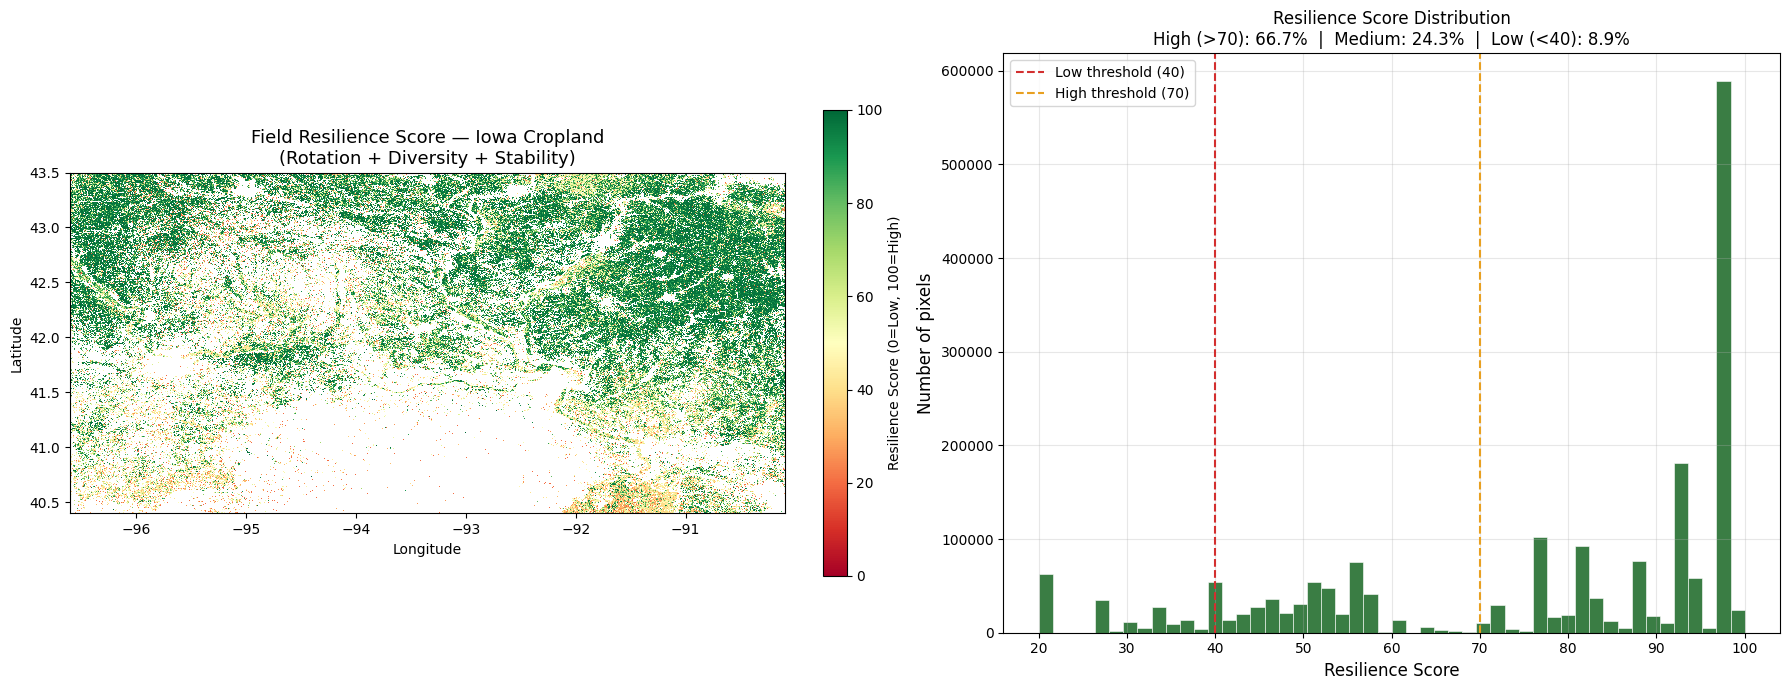

Saved → /content/drive/MyDrive/bitcamp/outputs/resilience_score_map.png


In [ ]:
# ── Plot Resilience Map ───────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Resilience score map ────────────────────────────────────────────────
cmap = plt.cm.RdYlGn
im = axes[0].imshow(
    resilience, cmap=cmap, vmin=0, vmax=100,
    extent=[IOWA_BBOX[0], IOWA_BBOX[2], IOWA_BBOX[1], IOWA_BBOX[3]],
    origin='upper', interpolation='nearest'
)
plt.colorbar(im, ax=axes[0], label='Resilience Score (0=Low, 100=High)', fraction=0.03)
axes[0].set_title('Field Resilience Score — Iowa Cropland\n(Rotation + Diversity + Stability)', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# ── Right: Score distribution histogram ──────────────────────────────────────
scores = resilience[cropland_mask]
scores = scores[~np.isnan(scores)]

n_high = np.sum(scores > 70)
n_med  = np.sum((scores >= 40) & (scores <= 70))
n_low  = np.sum(scores < 40)

axes[1].hist(scores, bins=50, color='#3A7D44', edgecolor='white', linewidth=0.4)
axes[1].axvline(40, color='#D32F2F', linestyle='--', linewidth=1.5, label='Low threshold (40)')
axes[1].axvline(70, color='#E8A020', linestyle='--', linewidth=1.5, label='High threshold (70)')
axes[1].set_xlabel('Resilience Score', fontsize=12)
axes[1].set_ylabel('Number of pixels', fontsize=12)
axes[1].set_title(
    f'Resilience Score Distribution\n'
    f'High (>70): {100*n_high/len(scores):.1f}%  |  '
    f'Medium: {100*n_med/len(scores):.1f}%  |  '
    f'Low (<40): {100*n_low/len(scores):.1f}%',
    fontsize=12
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
res_path = os.path.join(OUT_DIR, 'resilience_score_map.png')
plt.savefig(res_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {res_path}')

In [ ]:
# ── Save resilience stats CSV for Streamlit ───────────────────────────────────

# County-level summary (approximate using lat/lon grid cells)
# Divide Iowa into a 4x4 grid of regions
lat_bins = np.linspace(IOWA_BBOX[1], IOWA_BBOX[3], 5)
lon_bins = np.linspace(IOWA_BBOX[0], IOWA_BBOX[2], 5)

rows = []
for i in range(4):
    for j in range(4):
        # Create a rough spatial mask for this grid cell
        # Map grid indices to pixel indices in the downsampled raster
        h, w = ds_shape
        r0 = int(i * h/4); r1 = int((i+1) * h/4)
        c0 = int(j * w/4); c1 = int((j+1) * w/4)

        cell_res  = resilience[r0:r1, c0:c1]
        cell_crop = cropland_mask[r0:r1, c0:c1]
        cell_vals = cell_res[cell_crop & ~np.isnan(cell_res)]

        if len(cell_vals) < 100:
            continue

        lat_center = (lat_bins[i] + lat_bins[i+1]) / 2
        lon_center = (lon_bins[j] + lon_bins[j+1]) / 2

        rows.append({
            'Region':        f'Region {i*4+j+1}',
            'Lat':           round(lat_center, 2),
            'Lon':           round(lon_center, 2),
            'Mean_Score':    round(float(np.mean(cell_vals)), 1),
            'Pct_High':      round(float(100*np.mean(cell_vals > 70)), 1),
            'Pct_Low':       round(float(100*np.mean(cell_vals < 40)), 1),
            'N_Pixels':      int(len(cell_vals)),
        })

df_res = pd.DataFrame(rows)
res_csv = os.path.join(OUT_DIR, 'resilience_by_region.csv')
df_res.to_csv(res_csv, index=False)
print(df_res.to_string(index=False))
print(f'\nSaved → {res_csv}')

   Region   Lat    Lon  Mean_Score  Pct_High  Pct_Low  N_Pixels
 Region 1 40.79 -95.79        82.0      78.7      8.8    182809
 Region 2 40.79 -94.16        79.2      74.6     10.1    143448
 Region 3 40.79 -92.54        80.5      74.7      3.9    180373
 Region 4 40.79 -90.91        84.3      81.9      2.9    203330
 Region 5 41.56 -95.79        76.6      69.1      9.1    137732
 Region 6 41.56 -94.16        65.7      49.1     13.5    104874
 Region 7 41.56 -92.54        79.7      73.9      5.1    157235
 Region 8 41.56 -90.91        87.7      87.9      2.4    214631
 Region 9 42.34 -95.79        63.9      45.1     14.1     79544
Region 10 42.34 -94.16        70.1      57.2     11.3     75236
Region 11 42.34 -92.54        69.1      54.3      9.4     75067
Region 12 42.34 -90.91        72.7      61.7      7.3    167973
Region 13 43.11 -95.79        54.2      28.4     25.3     78247
Region 14 43.11 -94.16        39.2      10.6     56.2      5086
Region 15 43.11 -92.54        48.8      